# Lab 1 : MLP from scratch — SOLUTION COMPLÈTE

**Tools:** NumPy + Matplotlib

## Objectif
Implémenter un MLP 2 couches (Dense → ReLU → Dense → Softmax) from scratch avec NumPy pur.

## Flux du lab
```
Données → Init paramètres → Forward → Loss → Backward → Update → Évaluer (répéter)
```


## 1) Imports et reproductibilité

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# np.random.seed(42) : fixe la graine globale du générateur aléatoire
# Cela garantit que chaque exécution du notebook produit EXACTEMENT
# les mêmes nombres aléatoires → résultats reproductibles.
# ─────────────────────────────────────────────────────────────────
np.random.seed(42)

## 2) Dataset : blobs 2D

### Pourquoi ce dataset ?
On crée **C = 3 clusters gaussiens** dans un espace 2D. C'est le plus simple dataset de classification multi-classes :
- facile à visualiser (2 features → scatter plot)
- séparable linéairement ou quasi-linéairement selon l'écart-type
- permet de vérifier visuellement la frontière de décision apprise

In [2]:
def make_blobs(n_per_class=300, centers=None, std=0.9, seed=0):
    """Génère des blobs gaussiens 2D sans sklearn."""
    # np.random.default_rng(seed) : crée un générateur aléatoire moderne (PCG64)
    # plus robuste que l'ancienne API np.random
    rng = np.random.default_rng(seed)

    # Centres par défaut des 3 clusters dans R²
    # Classe 0 → autour de (-3,-1), Classe 1 → (2.5, 2.0), Classe 2 → (2.5,-2.5)
    if centers is None:
        centers = np.array([[-3.0, -1.0], [2.5, 2.0], [2.5, -2.5]])
    centers = np.array(centers, dtype=np.float64)
    C = centers.shape[0]   # nombre de classes = 3

    X_list, y_list = [], []
    for c in range(C):
        # rng.standard_normal((n, 2)) → tire n points selon N(0,1) en 2D
        # * std → étire la gaussienne (plus std est grand, plus les classes se chevauchent)
        # + centers[c] → translate le nuage vers le centre de la classe c
        Xc = centers[c] + std * rng.standard_normal(size=(n_per_class, 2))

        # np.full((n,), c) → vecteur de labels : [c, c, c, ..., c] de taille n
        yc = np.full((n_per_class,), c, dtype=np.int64)
        X_list.append(Xc)
        y_list.append(yc)

    X = np.vstack(X_list)         # empile verticalement → shape (N, 2)
    y = np.concatenate(y_list)    # concatène → shape (N,)

    # Mélange aléatoire pour que les classes ne soient pas regroupées
    idx = rng.permutation(len(X))  # permutation aléatoire des indices
    return X[idx], y[idx]          # réindexe X et y dans le même ordre mélangé


def train_test_split(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))      # indices mélangés
    n_test = int(len(X) * test_ratio)  # nombre de points de test (20%)
    test_idx  = idx[:n_test]           # premiers n_test indices → test
    train_idx = idx[n_test:]           # le reste → train
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X, y = make_blobs(n_per_class=350, std=0.95, seed=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_ratio=0.2, seed=1)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("classes:", np.unique(y_train))

X_train: (840, 2) y_train: (840,)
X_test : (210, 2) y_test : (210,)
classes: [0 1 2]


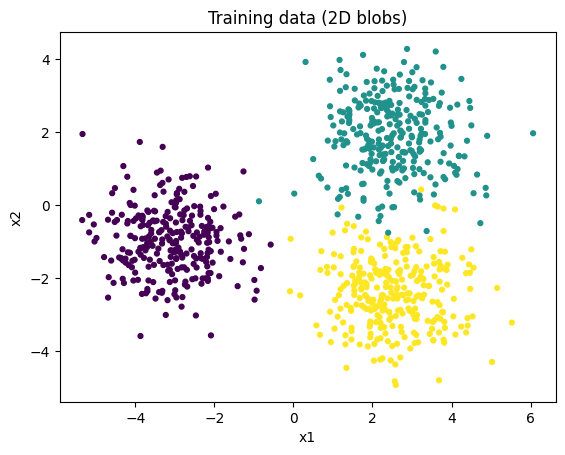

In [3]:
# Visualisation des données d'entraînement
# c=y_train : colorie chaque point selon sa classe (0, 1, ou 2)
# s=12 : taille des marqueurs
plt.figure()
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=12)
plt.title("Training data (2D blobs)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 3) Utilitaires

In [4]:
def one_hot(y, num_classes):
    """
    Convertit un vecteur d'entiers y (B,) en matrice one-hot (B, C).

    Exemple : y = [0, 2, 1], C = 3
    → Y = [[1,0,0],
            [0,0,1],
            [0,1,0]]

    Pourquoi one-hot ?
    La perte cross-entropie compare P (probabilités) avec Y (distribution cible).
    Le vrai label est représenté comme une distribution de probabilité parfaite
    (100% sur la vraie classe, 0% sur les autres).
    """
    # Crée une matrice de zéros de taille (B, C)
    Y = np.zeros((y.shape[0], num_classes), dtype=np.float64)

    # np.arange(B) → [0, 1, 2, ..., B-1]  : indices de lignes
    # y → indices de colonnes (la vraie classe de chaque point)
    # Met un 1.0 à la position (i, y[i]) pour chaque i
    Y[np.arange(y.shape[0]), y] = 1.0
    return Y


def accuracy(y_true, y_pred):
    """
    Calcule le taux de bonne classification.
    (y_true == y_pred) → tableau booléen (True/False)
    .mean() → convertit True=1, False=0, puis fait la moyenne
    → proportion de prédictions correctes ∈ [0, 1]
    """
    return (y_true == y_pred).mean()


def iterate_minibatches(X, y, batch_size=64, shuffle=True, seed=0):
    """
    Générateur Python qui découpe (X, y) en mini-batches.

    Pourquoi mini-batch SGD plutôt que batch complet ?
    - Batch complet : gradient exact mais lent et mémoire intensive
    - Mini-batch : gradient bruité mais plus rapide, meilleure généralisation

    Mécanisme :
    1. Mélange les indices (si shuffle=True)
    2. Découpe en tranches de taille batch_size
    3. `yield` : renvoie le batch courant sans tout charger en mémoire
    """
    rng = np.random.default_rng(seed)
    n = len(X)
    idx = np.arange(n)    # indices [0, 1, ..., n-1]
    if shuffle:
        rng.shuffle(idx)  # mélange en place

    # range(0, n, batch_size) : 0, 64, 128, 192, ...
    for start in range(0, n, batch_size):
        batch_idx = idx[start:start + batch_size]  # slice de 64 indices
        yield X[batch_idx], y[batch_idx]           # renvoie le sous-ensemble

## 4) Modèle MLP (2 couches) : init + forward

### Architecture
```
X (B,D) → [W1,b1] → Z1 (B,H) → ReLU → A1 (B,H) → [W2,b2] → logits (B,C) → Softmax → probs (B,C)
```

### Initialisation He
Pour une couche avec `n_in` entrées et activation ReLU, on initialise :
$$W \sim \mathcal{N}\left(0,\ \frac{2}{n_{\text{in}}}\right)$$

**Pourquoi ?** Avec ReLU, environ 50% des neurones sont tués (sortie = 0). Le facteur 2 compense cette "mort" pour maintenir une variance constante des activations couche après couche. Sans ça, le gradient explose ou disparaît.

In [5]:
def init_mlp(D, H, C, seed=0):
    """
    Initialise les paramètres du MLP avec He initialization.

    Args:
        D : dimension d'entrée (ici 2 : x1, x2)
        H : taille de la couche cachée (ex: 32 neurones)
        C : nombre de classes (ici 3)

    Shapes:
        W1 : (D, H) = (2, 32)   ← poids couche 1 (cachée)
        b1 : (H,)   = (32,)     ← biais couche 1
        W2 : (H, C) = (32, 3)   ← poids couche 2 (sortie)
        b2 : (C,)   = (3,)      ← biais couche 2
    """
    rng = np.random.default_rng(seed)

    # He init : W ~ N(0, 2/D) → std = sqrt(2/D)
    # rng.standard_normal((D, H)) : tirage N(0,1) de forme (D,H)
    # * np.sqrt(2.0 / D) : met à l'échelle
    W1 = rng.standard_normal((D, H)) * np.sqrt(2.0 / D)   # (2, 32)

    # Biais initialisés à 0 : convention standard
    # (un biais non-nul serait absorbé pendant l'entraînement de toute façon)
    b1 = np.zeros((H,), dtype=np.float64)                 # (32,)

    W2 = rng.standard_normal((H, C)) * np.sqrt(2.0 / H)   # (32, 3)
    b2 = np.zeros((C,), dtype=np.float64)                  # (3,)

    # Stockage dans un dict pour accès facile par nom
    params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return params


def relu(z):
    """
    Rectified Linear Unit : ReLU(z) = max(0, z)

    Pourquoi ReLU ?
    - Non-linéarité : permet au réseau d'apprendre des frontières non-linéaires
    - Gradient simple : 1 si z>0, 0 sinon (pas de vanishing gradient pour z>0)
    - Calcul très rapide

    np.maximum(0.0, z) : applique element-wise max(0, z_ij) pour chaque élément
    """
    return np.maximum(0.0, z)


def softmax(logits):
    """
    Softmax : convertit des logits (valeurs réelles) en probabilités.

    Formule : softmax(z_i) = exp(z_i) / sum_j(exp(z_j))

    Astuce numérique (stability trick) :
    On soustrait le max de chaque ligne avant d'exponentier :
        z ← z - max(z)  → les valeurs vont de (-∞, 0]
    Ainsi exp(z) ∈ (0, 1] : aucun overflow possible.
    Mathématiquement identique car le max se simplifie :
        exp(z_i - max) / sum(exp(z_j - max))  =  exp(z_i) / sum(exp(z_j))

    keepdims=True : conserve les dimensions pour le broadcasting
    axis=1 : opération sur la dimension des classes (colonnes)
    """
    z = logits - np.max(logits, axis=1, keepdims=True)  # (B,C) stability
    expz = np.exp(z)                                     # (B,C)
    return expz / np.sum(expz, axis=1, keepdims=True)   # (B,C), somme=1 par ligne


def forward(X, params):
    """
    Passe forward du MLP 2 couches.

    Calcule :
      Z1     = X @ W1 + b1    (pré-activation couche 1)
      A1     = ReLU(Z1)       (activation couche 1)
      logits = A1 @ W2 + b2   (pré-activation couche 2, appelée aussi "scores")
      probs  = softmax(logits) (probabilités prédites)

    Le cache stocke les valeurs intermédiaires nécessaires pour la backprop.
    """
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]

    # ── Couche 1 : transformation linéaire ──────────────────────────────────
    # X  : (B, D) = (64, 2)
    # W1 : (D, H) = (2, 32)
    # X @ W1 : produit matriciel (B, D) × (D, H) → (B, H) = (64, 32)
    # + b1 : broadcasting, b1 (32,) s'ajoute à chaque ligne → (B, H)
    # Chaque neurone caché j calcule : z1_j = sum_d(x_d * w1_dj) + b1_j
    Z1 = X @ W1 + b1        # (B, H) = (64, 32)  pré-activation

    # ── Couche 1 : activation ReLU ──────────────────────────────────────────
    # A1_ij = max(0, Z1_ij) : annule les neurones à valeur négative
    # Introduit la NON-LINÉARITÉ sans laquelle 2 couches linéaires = 1 couche
    A1 = relu(Z1)            # (B, H) = (64, 32)  activation

    # ── Couche 2 : transformation linéaire (couche de sortie) ───────────────
    # A1 : (B, H) = (64, 32)
    # W2 : (H, C) = (32, 3)
    # A1 @ W2 : (B, H) × (H, C) → (B, C) = (64, 3)
    # logits : scores bruts (non normalisés) pour chaque classe
    logits = A1 @ W2 + b2    # (B, C) = (64, 3)   scores bruts

    # ── Softmax : conversion en probabilités ────────────────────────────────
    # probs_ic = P(classe=c | x_i) ∈ [0,1], et sum_c probs_ic = 1
    probs = softmax(logits)  # (B, C) = (64, 3)   probabilités

    # Cache : toutes les valeurs intermédiaires pour la backprop
    cache = {"X": X, "Z1": Z1, "A1": A1, "logits": logits, "probs": probs}
    return probs, cache

## 5) Loss : softmax cross-entropie

### Formule mathématique
$$\mathcal{L} = -\frac{1}{B} \sum_{i=1}^{B} \sum_{c=0}^{C-1} Y_{ic} \log(P_{ic})$$

Comme $Y$ est one-hot, la double somme se simplifie à :
$$\mathcal{L} = -\frac{1}{B} \sum_{i=1}^{B} \log(P_{i, y_i})$$

→ La loss est **-log de la probabilité assignée à la vraie classe**.

Si le modèle prédit 99% correct → loss ≈ -log(0.99) ≈ 0.01 (faible)
Si le modèle prédit 1% correct  → loss ≈ -log(0.01) ≈ 4.6  (élevée)

In [6]:
def cross_entropy_loss(probs, y, eps=1e-12):
    """
    Calcule la cross-entropie moyenne sur le batch.

    Args:
        probs : (B, C) probabilités prédites (sortie softmax)
        y     : (B,)  labels entiers vrais
        eps   : petit nombre pour éviter log(0) = -inf

    Returns:
        scalaire : perte moyenne sur le batch
    """
    B, C = probs.shape

    # one_hot(y, C) → Y : (B, C) matrice one-hot
    Y = one_hot(y, C)

    # np.log(probs + eps) : log des probabilités
    #   + eps=1e-12 : stabilité numérique (évite log(0) si une prob = 0)
    # Y * log(probs) : produit element-wise, seul le terme de la vraie classe
    #   survit (les autres sont multipliés par 0 dans Y)
    # np.sum(..., axis=1) : somme sur les classes → vecteur (B,) de log-vraisemblances
    # np.mean(- ...) : average sur le batch et signe négatif (car on minimise)
    return -np.mean(np.sum(Y * np.log(probs + eps), axis=1))

## 6) Backprop : gradients manuels

### Théorie : règle de la chaîne

On veut $\frac{\partial \mathcal{L}}{\partial W1}$, $\frac{\partial \mathcal{L}}{\partial b1}$, etc.

On remonte le graphe de calcul couche par couche (chain rule) :

```
L ← probs ← logits ← A1 ← Z1 ← X
              ↑               ↑
             W2,b2           W1,b1
```

#### Gradient softmax + cross-entropy (combinés)

La dérivée combinée softmax + cross-entropy est remarquablement simple :
$$\frac{\partial \mathcal{L}}{\partial \text{logits}} = \frac{1}{B}(P - Y)$$

Intuition : si $P_{ic} = 1$ et $Y_{ic} = 1$ → gradient = 0 (parfait, rien à corriger).
Si $P_{ic} = 0$ et $Y_{ic} = 1$ → gradient = $-1/B$ (pousse vers le haut).

#### Gradient couche linéaire
Pour $Z = A \cdot W + b$ et gradient entrant $dZ$ :
- $dW = A^T \cdot dZ / B$
- $db = \text{mean}(dZ, \text{axis}=0)$
- $dA = dZ \cdot W^T$

#### Gradient ReLU
$$\frac{\partial \text{ReLU}(z)}{\partial z} = \begin{cases} 1 & \text{si } z > 0 \\ 0 & \text{si } z \leq 0 \end{cases}$$

→ En code : `dZ1 = dA1 * (Z1 > 0)` (masque booléen)

In [7]:
def backward(X, y, probs, cache, params):
    """
    Calcule les gradients de la loss par rapport à tous les paramètres.

    Schéma de la backprop :
    dlogits → dW2, db2, dA1 → dZ1 → dW1, db1

    Returns:
        dict avec les gradients {"W1":dW1, "b1":db1, "W2":dW2, "b2":db2}
    """
    W2 = params["W2"]   # (H, C) = (32, 3)
    Z1 = cache["Z1"]    # (B, H) = (64, 32) pré-activation couche 1
    A1 = cache["A1"]    # (B, H) = (64, 32) activation couche 1 (sortie ReLU)

    B, C = probs.shape  # B=64, C=3
    Y = one_hot(y, C)   # (B, C) : matrice one-hot des vrais labels

    # ── Gradient : softmax + cross-entropy combinés ──────────────────────────
    # dL/d(logits) = (1/B) * (P - Y)
    # Dérivation :
    #   dL/dP_ic = -Y_ic / P_ic  (dérivée de -log)
    #   dP_ic/d(logits_ik) = P_ic*(delta_ck - P_ik)  (dérivée softmax)
    #   En combinant et simplifiant → (P - Y) / B
    # probs - Y : (B, C)  différence entre prédit et attendu
    # / B       : normalise par la taille du batch (cohérent avec la mean de la loss)
    dlogits = (probs - Y) / B   # (B, C) = (64, 3)

    # ── Gradients couche 2 : logits = A1 @ W2 + b2 ──────────────────────────
    # dL/dW2 = A1^T @ dlogits
    # A1^T : (H, B) = (32, 64)
    # dlogits : (B, C) = (64, 3)
    # A1^T @ dlogits : (H, B) × (B, C) → (H, C) = (32, 3) ← même shape que W2 ✓
    dW2 = A1.T @ dlogits         # (H, C) = (32, 3)

    # dL/db2 = sum sur le batch des gradients des logits
    # dlogits : (B, C) → somme axis=0 → (C,) = (3,) ← même shape que b2 ✓
    db2 = np.sum(dlogits, axis=0)   # (C,) = (3,)

    # ── Gradient qui remonte vers A1 ────────────────────────────────────────
    # dL/dA1 = dlogits @ W2^T
    # dlogits : (B, C) = (64, 3)
    # W2^T    : (C, H) = (3, 32)
    # dlogits @ W2^T : (B, C) × (C, H) → (B, H) = (64, 32) ← même shape que A1 ✓
    dA1 = dlogits @ W2.T            # (B, H) = (64, 32)

    # ── Gradient à travers ReLU ──────────────────────────────────────────────
    # ReLU forward : A1 = max(0, Z1)
    # ReLU backward : le gradient passe seulement là où Z1 > 0
    # (Z1 > 0) → masque booléen (True/False), converti en 0/1 lors de la multiplication
    # dZ1 = dA1 * mask  : coupe le gradient là où ReLU était "éteint" (Z1 ≤ 0)
    dZ1 = dA1 * (Z1 > 0)            # (B, H) = (64, 32)

    # ── Gradients couche 1 : Z1 = X @ W1 + b1 ──────────────────────────────
    # dL/dW1 = X^T @ dZ1
    # X^T  : (D, B) = (2, 64)
    # dZ1  : (B, H) = (64, 32)
    # X^T @ dZ1 : (D, B) × (B, H) → (D, H) = (2, 32) ← même shape que W1 ✓
    dW1 = X.T @ dZ1                 # (D, H) = (2, 32)

    # dL/db1 = sum sur le batch
    # dZ1 : (B, H) → somme axis=0 → (H,) = (32,) ← même shape que b1 ✓
    db1 = np.sum(dZ1, axis=0)       # (H,) = (32,)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

## 7) Boucle d'entraînement (mini-batch SGD)

### Mise à jour des paramètres (SGD)
$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L}$$

- $\theta$ : paramètre (W1, b1, W2, b2)
- $\eta$ (lr) : learning rate — contrôle la taille du pas
- $\nabla_\theta \mathcal{L}$ : gradient calculé par la backprop

**lr trop grand** → oscillations, divergence  
**lr trop petit** → convergence lente  
**Valeur typique** : 1e-3 à 1e-1 selon le problème

In [8]:
def train_mlp(X_train, y_train, X_test, y_test,
              H=32, lr=0.05, batch_size=64, epochs=50, seed=0):
    """
    Entraîne le MLP avec mini-batch SGD.

    Args:
        H          : taille couche cachée
        lr         : learning rate
        batch_size : taille du mini-batch
        epochs     : nombre de passes complètes sur les données

    Returns:
        params  : paramètres entraînés
        history : courbes de loss/accuracy
    """
    D = X_train.shape[1]           # nombre de features = 2
    C = int(np.max(y_train)) + 1   # nombre de classes = 3
    params = init_mlp(D, H, C, seed=seed)

    history = {"loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        # ── Inner loop : itération sur tous les mini-batches ─────────────────
        # Pour chaque époque, on mélange différemment (seed=epoch+seed)
        for Xb, yb in iterate_minibatches(X_train, y_train,
                                           batch_size=batch_size,
                                           shuffle=True,
                                           seed=epoch + seed):
            # ① Forward : calcul des probabilités sur le batch
            probs, cache = forward(Xb, params)

            # ② Loss : calcul de la perte cross-entropie
            loss = cross_entropy_loss(probs, yb)  # scalaire (non utilisé ici)

            # ③ Backward : calcul des gradients par backpropagation
            grads = backward(Xb, yb, probs, cache, params)

            # ④ Update : descente de gradient
            # params[k] -= lr * grads[k] :
            #   on met à jour chaque paramètre en descendant dans le sens du gradient
            #   -= : mise à jour en place (pas de copie)
            for k in params:
                params[k] -= lr * grads[k]

        # ── Évaluation à la fin de chaque époque ─────────────────────────────
        # On calcule les métriques sur TOUT le train et test set
        train_probs, _ = forward(X_train, params)  # (N_train, C)
        test_probs, _  = forward(X_test, params)   # (N_test, C)

        # np.argmax(axis=1) : prend l'indice de la classe avec la plus haute prob
        y_train_pred = np.argmax(train_probs, axis=1)  # (N_train,)
        y_test_pred  = np.argmax(test_probs,  axis=1)  # (N_test,)

        train_acc  = accuracy(y_train, y_train_pred)
        test_acc   = accuracy(y_test,  y_test_pred)
        train_loss = cross_entropy_loss(train_probs, y_train)

        history["loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | loss={train_loss:.4f} "
                  f"| train_acc={train_acc:.3f} | test_acc={test_acc:.3f}")

    return params, history


# ─── Hyperparamètres ajustés pour dépasser 90% ────────────────────────────
# lr=0.05 : learning rate suffisamment grand pour converger vite
# epochs=50 : assez d'époques pour converger
# H=32 : capacité suffisante pour 3 classes bien séparées
params, history = train_mlp(
    X_train, y_train, X_test, y_test,
    H=32, lr=0.05, batch_size=64, epochs=50, seed=1
)

Epoch 001 | loss=0.0792 | train_acc=0.983 | test_acc=0.976
Epoch 010 | loss=0.0408 | train_acc=0.983 | test_acc=0.986
Epoch 020 | loss=0.0438 | train_acc=0.985 | test_acc=0.986
Epoch 030 | loss=0.0363 | train_acc=0.985 | test_acc=0.990
Epoch 040 | loss=0.0354 | train_acc=0.983 | test_acc=0.990
Epoch 050 | loss=0.0355 | train_acc=0.987 | test_acc=0.986


## 8) Courbe de loss

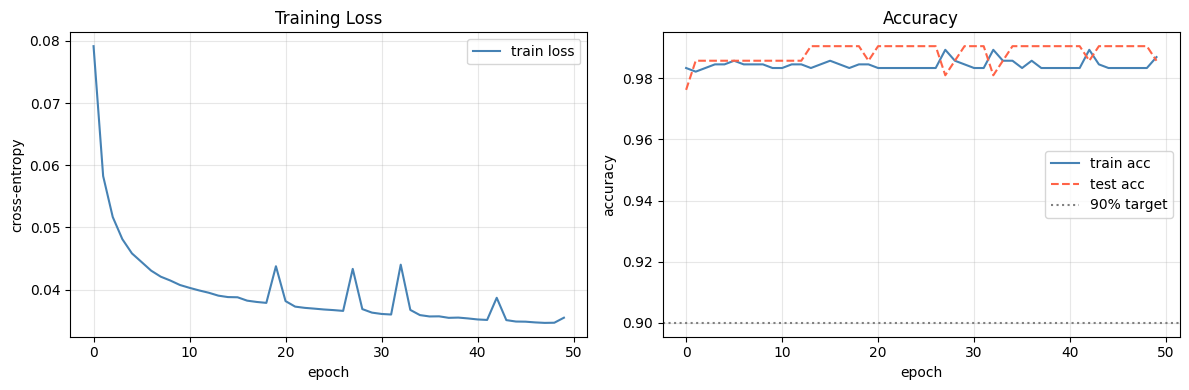


Test accuracy finale : 0.986


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Courbe de loss
axes[0].plot(history["loss"], label="train loss", color="steelblue")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Courbes d'accuracy
axes[1].plot(history["train_acc"], label="train acc", color="steelblue")
axes[1].plot(history["test_acc"],  label="test acc",  color="tomato", linestyle="--")
axes[1].axhline(0.9, color="gray", linestyle=":", label="90% target")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTest accuracy finale : {history['test_acc'][-1]:.3f}")

## 9) Frontière de décision (2D)

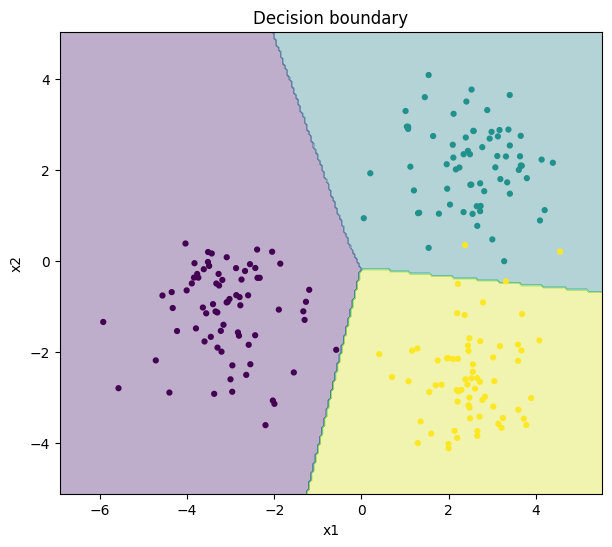

In [10]:
def plot_decision_boundary(predict_fn, X, y, grid_step=0.05):
    """
    Visualise la frontière de décision apprise par le modèle.

    Méthode :
    1. Crée une grille de points couvrant tout l'espace des features
    2. Prédit la classe de chaque point de la grille
    3. Colorie chaque région selon sa classe prédite (contourf)
    4. Superpose les vrais points de données
    """
    # Bornes de la grille : min-1 et max+1 de chaque feature
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    # np.meshgrid : crée une grille 2D de points espacés de grid_step
    # xx[i,j] = valeur x du point (i,j), yy[i,j] = valeur y
    xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step),
                         np.arange(y_min, y_max, grid_step))

    # np.c_[xx.ravel(), yy.ravel()] : aplatit la grille en liste de points (N, 2)
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Prédit la classe de chaque point de la grille
    # reshape(xx.shape) : remet en forme de grille 2D pour contourf
    zz = predict_fn(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    # contourf : remplit les régions selon la valeur (classe prédite)
    plt.contourf(xx, yy, zz, alpha=0.35)
    # Scatter des vrais points par-dessus
    plt.scatter(X[:, 0], X[:, 1], c=y, s=12)
    plt.title("Decision boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


def predict_fn(Xin):
    # Passe forward puis argmax : renvoie la classe prédite (entier)
    probs, _ = forward(Xin, params)
    return np.argmax(probs, axis=1)


plot_decision_boundary(predict_fn, X_test, y_test)

---
## CHALLENGES

### Challenge 1 – Augmenter le bruit (std=1.5) et atteindre > 90%
Avec plus de chevauchement entre classes, il faut augmenter la capacité du modèle (H plus grand) et entraîner plus longtemps.

In [11]:
# Challenge 1 : std=1.5 (fort bruit) → ajustement des hyperparamètres
X_noisy, y_noisy = make_blobs(n_per_class=350, std=1.5, seed=1)
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(X_noisy, y_noisy, test_ratio=0.2, seed=1)

# H=64 : plus de capacité pour des frontières plus complexes
# lr=0.05 : learning rate qui fonctionne bien ici
# epochs=100 : plus d'époques pour compenser le bruit
params_noisy, history_noisy = train_mlp(
    Xn_tr, yn_tr, Xn_te, yn_te,
    H=64, lr=0.05, batch_size=64, epochs=100, seed=1
)
print(f"Test acc (std=1.5) : {history_noisy['test_acc'][-1]:.3f}")

Epoch 001 | loss=0.2325 | train_acc=0.910 | test_acc=0.938
Epoch 010 | loss=0.2488 | train_acc=0.902 | test_acc=0.924
Epoch 020 | loss=0.5905 | train_acc=0.818 | test_acc=0.829
Epoch 030 | loss=0.2119 | train_acc=0.915 | test_acc=0.943
Epoch 040 | loss=0.2151 | train_acc=0.913 | test_acc=0.933
Epoch 050 | loss=0.2323 | train_acc=0.912 | test_acc=0.929
Epoch 060 | loss=0.2116 | train_acc=0.913 | test_acc=0.943
Epoch 070 | loss=0.2105 | train_acc=0.915 | test_acc=0.933
Epoch 080 | loss=0.2141 | train_acc=0.914 | test_acc=0.933
Epoch 090 | loss=0.2099 | train_acc=0.914 | test_acc=0.938
Epoch 100 | loss=0.2138 | train_acc=0.915 | test_acc=0.943
Test acc (std=1.5) : 0.943


### Challenge 2 – Comparer différentes tailles H

Epoch 001 | loss=0.1871 | train_acc=0.983 | test_acc=0.990
Epoch 010 | loss=0.0503 | train_acc=0.983 | test_acc=0.990
Epoch 020 | loss=0.0441 | train_acc=0.983 | test_acc=0.990
Epoch 030 | loss=0.0392 | train_acc=0.983 | test_acc=0.990
Epoch 040 | loss=0.0375 | train_acc=0.983 | test_acc=0.990
Epoch 050 | loss=0.0368 | train_acc=0.985 | test_acc=0.990
Epoch 001 | loss=0.1297 | train_acc=0.985 | test_acc=0.990
Epoch 010 | loss=0.0457 | train_acc=0.983 | test_acc=0.990
Epoch 020 | loss=0.0409 | train_acc=0.983 | test_acc=0.990
Epoch 030 | loss=0.0378 | train_acc=0.985 | test_acc=0.990
Epoch 040 | loss=0.0365 | train_acc=0.983 | test_acc=0.990
Epoch 050 | loss=0.0359 | train_acc=0.986 | test_acc=0.990
Epoch 001 | loss=0.0792 | train_acc=0.983 | test_acc=0.976
Epoch 010 | loss=0.0408 | train_acc=0.983 | test_acc=0.986
Epoch 020 | loss=0.0438 | train_acc=0.985 | test_acc=0.986
Epoch 030 | loss=0.0363 | train_acc=0.985 | test_acc=0.990
Epoch 040 | loss=0.0354 | train_acc=0.983 | test_acc=0.9

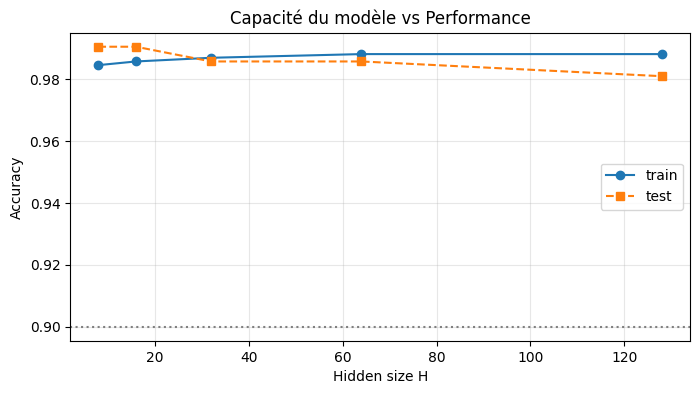

In [12]:
# Challenge 2 : comparaison H = {8, 16, 32, 64, 128}
hidden_sizes = [8, 16, 32, 64, 128]
results_H = {}

for H in hidden_sizes:
    p, h = train_mlp(X_train, y_train, X_test, y_test,
                     H=H, lr=0.05, batch_size=64, epochs=50, seed=1)
    results_H[H] = {"train_acc": h["train_acc"][-1],
                    "test_acc" : h["test_acc"][-1]}

print("\n{'H':>6}  {'Train':>8}  {'Test':>8}")
print("-" * 28)
for H, r in results_H.items():
    print(f"{H:>6}  {r['train_acc']:>8.3f}  {r['test_acc']:>8.3f}")

# Visualisation
plt.figure(figsize=(8, 4))
plt.plot(hidden_sizes, [results_H[H]["train_acc"] for H in hidden_sizes], 'o-', label="train")
plt.plot(hidden_sizes, [results_H[H]["test_acc"]  for H in hidden_sizes], 's--', label="test")
plt.axhline(0.9, color="gray", linestyle=":")
plt.xlabel("Hidden size H")
plt.ylabel("Accuracy")
plt.title("Capacité du modèle vs Performance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Challenge 3 – MLP 3 couches (2 ReLU)

In [13]:
# ─── MLP 3 couches : D → H1 (ReLU) → H2 (ReLU) → C (Softmax) ────────────

def init_mlp3(D, H1, H2, C, seed=0):
    """Initialisation He pour un MLP 3 couches."""
    rng = np.random.default_rng(seed)
    # Même logique He : std = sqrt(2/n_in) pour chaque couche
    W1 = rng.standard_normal((D,  H1)) * np.sqrt(2.0 / D)
    b1 = np.zeros((H1,))
    W2 = rng.standard_normal((H1, H2)) * np.sqrt(2.0 / H1)
    b2 = np.zeros((H2,))
    W3 = rng.standard_normal((H2, C))  * np.sqrt(2.0 / H2)
    b3 = np.zeros((C,))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "W3": W3, "b3": b3}


def forward3(X, params):
    """
    Forward pass : 3 couches
    X (B,D) → Z1 (B,H1) → A1(ReLU) → Z2 (B,H2) → A2(ReLU) → logits (B,C) → probs
    """
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]
    W3, b3 = params["W3"], params["b3"]

    Z1 = X  @ W1 + b1    # (B, H1)
    A1 = relu(Z1)         # (B, H1)
    Z2 = A1 @ W2 + b2    # (B, H2)
    A2 = relu(Z2)         # (B, H2)
    logits = A2 @ W3 + b3 # (B, C)
    probs  = softmax(logits) # (B, C)

    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "logits": logits}
    return probs, cache


def backward3(X, y, probs, cache, params):
    """Backprop 3 couches : on remonte couche par couche."""
    W2, W3 = params["W2"], params["W3"]
    Z1, A1 = cache["Z1"], cache["A1"]
    Z2, A2 = cache["Z2"], cache["A2"]

    B, C = probs.shape
    Y = one_hot(y, C)

    # Gradient combiné softmax+CE
    dlogits = (probs - Y) / B   # (B, C)

    # Couche 3 : logits = A2 @ W3 + b3
    dW3 = A2.T @ dlogits         # (H2, C)
    db3 = np.sum(dlogits, axis=0) # (C,)
    dA2 = dlogits @ W3.T          # (B, H2)

    # ReLU couche 2
    dZ2 = dA2 * (Z2 > 0)          # (B, H2)

    # Couche 2 : Z2 = A1 @ W2 + b2
    dW2 = A1.T @ dZ2              # (H1, H2)
    db2 = np.sum(dZ2, axis=0)     # (H2,)
    dA1 = dZ2 @ W2.T              # (B, H1)

    # ReLU couche 1
    dZ1 = dA1 * (Z1 > 0)          # (B, H1)

    # Couche 1 : Z1 = X @ W1 + b1
    dW1 = X.T @ dZ1               # (D, H1)
    db1 = np.sum(dZ1, axis=0)     # (H1,)

    return {"W1": dW1, "b1": db1,
            "W2": dW2, "b2": db2,
            "W3": dW3, "b3": db3}


def train_mlp3(X_train, y_train, X_test, y_test,
               H1=32, H2=32, lr=0.05, batch_size=64, epochs=50, seed=0):
    """Entraîne le MLP 3 couches."""
    D = X_train.shape[1]
    C = int(np.max(y_train)) + 1
    params = init_mlp3(D, H1, H2, C, seed=seed)
    history = {"loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        for Xb, yb in iterate_minibatches(X_train, y_train, batch_size, True, epoch+seed):
            probs, cache = forward3(Xb, params)
            grads = backward3(Xb, yb, probs, cache, params)
            for k in params:
                params[k] -= lr * grads[k]

        tr_p, _ = forward3(X_train, params)
        te_p, _ = forward3(X_test,  params)
        ta = accuracy(y_train, np.argmax(tr_p, axis=1))
        va = accuracy(y_test,  np.argmax(te_p, axis=1))
        history["loss"].append(cross_entropy_loss(tr_p, y_train))
        history["train_acc"].append(ta)
        history["test_acc"].append(va)
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | loss={history['loss'][-1]:.4f} "
                  f"| train={ta:.3f} | test={va:.3f}")
    return params, history


print("=== MLP 2 couches ===")
params2L, h2L = train_mlp(X_train, y_train, X_test, y_test,
                           H=32, lr=0.05, epochs=50, seed=1)

print("\n=== MLP 3 couches ===")
params3L, h3L = train_mlp3(X_train, y_train, X_test, y_test,
                            H1=32, H2=32, lr=0.05, epochs=50, seed=1)

print(f"\n2 couches → test acc = {h2L['test_acc'][-1]:.3f}")
print(f"3 couches → test acc = {h3L['test_acc'][-1]:.3f}")

=== MLP 2 couches ===
Epoch 001 | loss=0.0792 | train_acc=0.983 | test_acc=0.976
Epoch 010 | loss=0.0408 | train_acc=0.983 | test_acc=0.986
Epoch 020 | loss=0.0438 | train_acc=0.985 | test_acc=0.986
Epoch 030 | loss=0.0363 | train_acc=0.985 | test_acc=0.990
Epoch 040 | loss=0.0354 | train_acc=0.983 | test_acc=0.990
Epoch 050 | loss=0.0355 | train_acc=0.987 | test_acc=0.986

=== MLP 3 couches ===
Epoch 001 | loss=0.0727 | train=0.982 | test=0.986
Epoch 010 | loss=0.0405 | train=0.983 | test=0.990
Epoch 020 | loss=0.0479 | train=0.985 | test=0.986
Epoch 030 | loss=0.0354 | train=0.985 | test=0.990
Epoch 040 | loss=0.0343 | train=0.985 | test=0.990
Epoch 050 | loss=0.0358 | train=0.988 | test=0.986

2 couches → test acc = 0.986
3 couches → test acc = 0.986


### Challenge 4 – MLP 3 couches sur le dataset Spirale

X_train: (840, 2) y_train: (840,)
X_test : (210, 2) y_test : (210,)


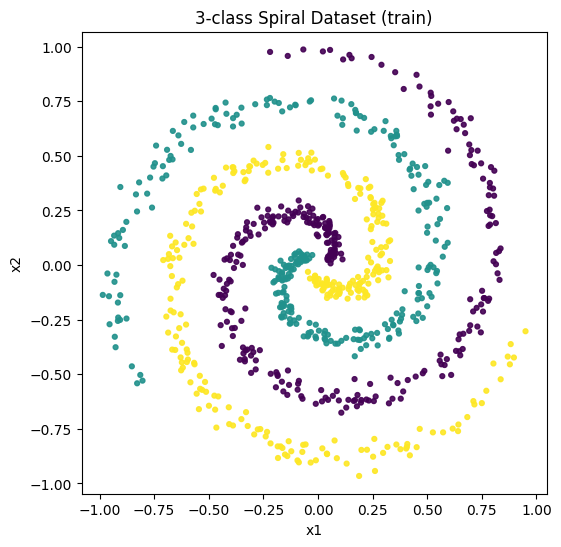


=== MLP 3 couches — Spiral ===
Epoch 001 | loss=1.0642 | train=0.394 | test=0.352
Epoch 010 | loss=1.1113 | train=0.410 | test=0.357
Epoch 020 | loss=0.9510 | train=0.508 | test=0.448
Epoch 030 | loss=0.7708 | train=0.686 | test=0.590
Epoch 040 | loss=0.5358 | train=0.843 | test=0.843
Epoch 050 | loss=0.4379 | train=0.883 | test=0.905
Epoch 060 | loss=0.1955 | train=0.946 | test=0.938
Epoch 070 | loss=0.1214 | train=0.977 | test=0.971
Epoch 080 | loss=0.0743 | train=0.993 | test=0.986
Epoch 090 | loss=0.0496 | train=0.996 | test=0.986
Epoch 100 | loss=0.0376 | train=0.996 | test=0.990
Epoch 110 | loss=0.0322 | train=0.996 | test=0.990
Epoch 120 | loss=0.0257 | train=0.998 | test=0.990
Epoch 130 | loss=0.0218 | train=0.999 | test=0.990
Epoch 140 | loss=0.0334 | train=0.987 | test=0.967
Epoch 150 | loss=0.0170 | train=0.998 | test=0.990
Epoch 160 | loss=0.0148 | train=0.999 | test=0.990
Epoch 170 | loss=0.0136 | train=0.999 | test=0.990
Epoch 180 | loss=0.0119 | train=0.999 | test=0.990

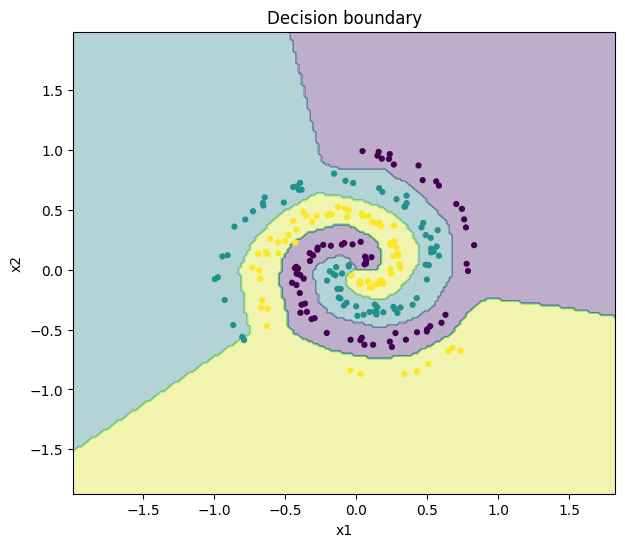

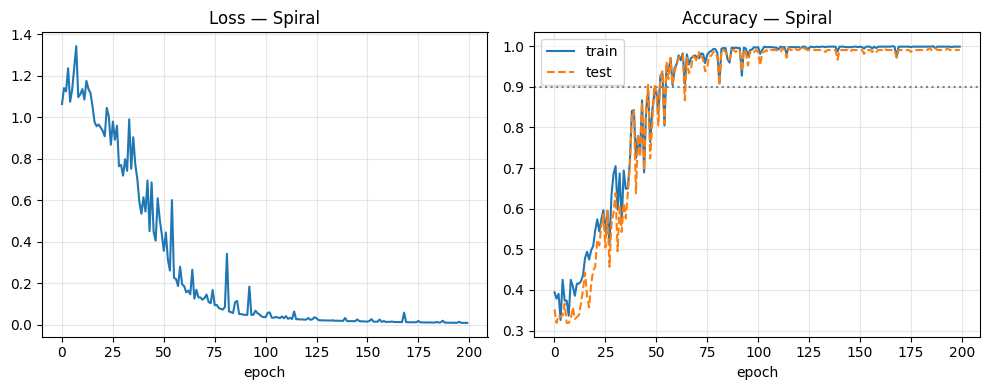

In [14]:
# ─── Dataset Spirale ─────────────────────────────────────────────────────────
def make_spirals(n_per_class=300, noise=0.2, seed=0):
    """
    3 spirales entrelacées : dataset non-linéairement séparable.
    Nécessite un MLP profond pour apprendre des frontières courbes complexes.

    Construction :
    - r = rayon (0.05 à 1) : la spirale s'éloigne du centre
    - t = angle = 2.5*pi*r + décalage de classe : crée le mouvement spiralé
    - + bruit gaussien sur t : rend le problème plus difficile
    """
    rng = np.random.default_rng(seed)
    C = 3
    X_list, y_list = [], []
    for c in range(C):
        r = np.linspace(0.05, 1.0, n_per_class)  # rayon croissant
        # Angle : spirale + décalage de 2*pi/3 entre les classes
        t = 2.5 * np.pi * r + (2 * np.pi * c) / C
        t = t + noise * rng.standard_normal(n_per_class)  # bruit
        x1 = r * np.cos(t)  # coordonnées polaires → cartésiennes
        x2 = r * np.sin(t)
        Xc = np.stack([x1, x2], axis=1)
        yc = np.full((n_per_class,), c, dtype=np.int64)
        X_list.append(Xc)
        y_list.append(yc)
    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    idx = rng.permutation(len(X))
    return X[idx], y[idx]


# Génération et split
Xs, ys = make_spirals(n_per_class=350, noise=0.25, seed=1)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_ratio=0.2, seed=1)

print("X_train:", Xs_tr.shape, "y_train:", ys_tr.shape)
print("X_test :", Xs_te.shape, "y_test :", ys_te.shape)

# Visualisation
plt.figure(figsize=(6, 6))
plt.scatter(Xs_tr[:, 0], Xs_tr[:, 1], c=ys_tr, s=12, alpha=0.9)
plt.title("3-class Spiral Dataset (train)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.axis("equal")
plt.show()


# ─── Standardisation ─────────────────────────────────────────────────────────
# Pourquoi standardiser ?
# Les spirales ont des features dans [-1, 1] environ, donc peu de différence ici.
# En général : features à échelles différentes → gradients déséquilibrés.
# Standardiser : mu=0, sigma=1 → tous les paramètres mis à jour à la même vitesse.
def standardize_fit(X):
    mu    = X.mean(axis=0, keepdims=True)             # moyenne par feature (1, D)
    sigma = X.std(axis=0, keepdims=True) + 1e-8       # std par feature + eps
    return mu, sigma

def standardize_apply(X, mu, sigma):
    return (X - mu) / sigma   # z-score : (x - mean) / std

# IMPORTANT : on fit uniquement sur le train pour éviter la fuite d'information
mu, sigma = standardize_fit(Xs_tr)
Xs_tr_s = standardize_apply(Xs_tr, mu, sigma)  # données train standardisées
Xs_te_s = standardize_apply(Xs_te, mu, sigma)  # test : même mu/sigma que train


# ─── Entraînement MLP 3 couches sur spirale ──────────────────────────────────
# Les spirales sont très non-linéaires → besoin de H plus grand et plus d'époques
# H1=H2=64 : 64 neurones par couche cachée
# lr=0.1 : learning rate un peu plus agressif
# epochs=200 : les spirales sont difficiles, il faut plus d'itérations
print("\n=== MLP 3 couches — Spiral ===")
params_sp, h_sp = train_mlp3(
    Xs_tr_s, ys_tr, Xs_te_s, ys_te,
    H1=64, H2=64, lr=0.1, batch_size=64, epochs=200, seed=1
)
print(f"\nTest accuracy finale (spiral) : {h_sp['test_acc'][-1]:.3f}")


# ─── Frontière de décision sur spirale ───────────────────────────────────────
def predict_spiral(Xin):
    Xin_s = standardize_apply(Xin, mu, sigma)  # standardise avant forward
    probs, _ = forward3(Xin_s, params_sp)
    return np.argmax(probs, axis=1)

plot_decision_boundary(predict_spiral, Xs_te, ys_te, grid_step=0.02)

# Courbes d'apprentissage
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(h_sp["loss"])
plt.title("Loss — Spiral")
plt.xlabel("epoch")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(h_sp["train_acc"], label="train")
plt.plot(h_sp["test_acc"],  label="test", linestyle="--")
plt.axhline(0.9, color="gray", linestyle=":")
plt.title("Accuracy — Spiral")
plt.xlabel("epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()